# Recreate the plant graph

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pathresults = "../scripts/results/"
#pathresults = "/DUMUXDune27/DUMUX/dumux-rosi/python/paperSc/results/"
data_file_delimiter = ","
import re

evalTime = 25.

In [7]:
def getVal(mypath, filename,dtype=float,extension='.txt', header="infer",names = None):
    fullpath = pathresults +mypath+filename
    data_file_delimiter = ","
    if names is None:
        largest_column_count = 0
        with open(fullpath, 'r') as temp_f:
            lines = temp_f.readlines()
        last_line = lines[-1].strip()
        #print('last_line',last_line)
        array_from_last_line = np.array(last_line.split(','), dtype=dtype)
        largest_column_count = len(array_from_last_line)
        names = [i for i in range(0, largest_column_count)]
        cst = pd.read_csv(fullpath,delimiter=data_file_delimiter, 
                          header = header, names = names,dtype=dtype)
        #print('cst',cst.shape)
    else:
        cst = pd.read_csv(fullpath,delimiter=data_file_delimiter, header = header, names = names)
    return cst
    
def get_last_line_as_numpy_array(file_path,  dtype = float, verbose = False):
    with open(pathresults +file_path, 'r') as file:
        # Read all lines
        lines = file.readlines()

        # Check if there are any lines in the file
        if not lines:
            raise ValueError("The file is empty")

        # Get the last line
        
        try:
            last_line = lines[-1].strip()
        except:
            print('timeLine',file_path, len(lines))
            raise Exception

        # Split the last line by commas and convert to NumPy array
        array_from_last_line = np.array(last_line.split(','), dtype=dtype)
        if verbose:
            print(file_path, len(array_from_last_line), end=", ")

        return array_from_last_line

def getCylIdx(path2file):
    fileName = "rhizoSegsId.txt"
    fullpath = path2file+fileName
    rhizoSegsId = get_last_line_as_numpy_array(fullpath, dtype = int, verbose = True)
    print('rhizoSegsId',max(rhizoSegsId))
    return rhizoSegsId
    
def list_files_with_prefix(folder_path, prefix):
    file_names = []
    for file_name in os.listdir(pathresults+folder_path):
        if file_name.startswith(prefix):
            file_names.append(file_name)
    return file_names

# cylinder max konz (per cell)
def getData_(cid,gId,path2file):
    fileName = "cyl_val/Cyl_cellVol_"+str(gId)+".txt"
    cVol = get_last_line_as_numpy_array(path2file+fileName, dtype = float)
    if cid == volIdx:
        return sum(cVol)
    elif cid <= 9:
        if cid <= 2:# == 0:
            fileName = "cyl_val/Cyl_watercontent_"+str(gId)+".txt"
            theta = get_last_line_as_numpy_array(path2file+fileName,dtype = float)
            cVol *= theta#cm3 scv to cm3 water
            if cid == 0:
                return sum(cVol)
        fileName = "cyl_val/Cyl_content"+str(cid)+"_"+str(gId)+".txt"
        Q1 = get_last_line_as_numpy_array(path2file+fileName,  dtype = float)
        konz = sum(Q1)/sum(cVol) #mol/cm3 or cm3/cm3
        return konz
    raise Exception

plantData = ['Q_Ag','Q_Rm','Q_Gr', 'Q_Exud_tot', 'Q_Mucil_tot',
             'Q_Exud','Q_Mucil','Q_S_ST','Q_S_meso',
             'trans' ,'psiXyl','nodes_Z','segments_nodeX',
             'time','Qlight','pSet','scenario' ]

#extensions = {0:'.txt',1:'.txt',2:'.txt',3: '.txt', 4:'.txt',
#             5:'.txt',
#             6:'.txt', 7:'.txt',8:'.txt', 9:'.txt', 10:'.txt',
#              11:'.txt',12:'.txt',13:'.txt'}
colNames=np.array(list(plantData))
nToGet = len(plantData)-4 # all except pset and scenario

scenarios = [ "baseline", "lateDry","earlyDry"]
setIds =[5,44,61]# ,44,49 [7,21, 47, 85]
exceptPset = []#[('baseline','19'),('baseline','47'),('baseline','83')]
# result_list_compExcept = [path2file.format(scenario, str(setId)) for scenario, setId in exceptPsets]
dataInput =  [(scenario, str(setId)) for scenario in scenarios 
              for setId in setIds if (scenario, str(setId)) 
              not in exceptPset ]
# result_list_comp = [path2file.format(dI[0], dI[1]) 
#                    for dI in dataInput]

# numPset = len(dataInput)


def getData():
    
    GiniAll = [[] for i in range(len(dataInput))]
    
    for idSet, dI in enumerate(dataInput):
        GiniAll_ = pd.DataFrame(columns=colNames)
        print(idSet,end =", ")

        path2file = path2file_.format(dI[0], dI[1])
        #print(path2file)

        time = np.array(list(
            pd.read_csv(pathresults + path2file + "time.txt", 
                           names = ["time","Qlight"])["time"][1:])) # because we have twice the initial value
        Qlight =  np.array(list(
            pd.read_csv(pathresults + path2file + "time.txt", 
                           names = ["time","Qlight"])["Qlight"][1:])) # because we have twice the initial value
        timemax = int((max(time))*10)/10
        print('timemax',max(time),timemax, len(time))
        
        if(True):#timemax==25):


            for cid in range(nToGet):
                if (plantData[cid] == 'psiXyl'):
                    Ginits = getVal(path2file,plantData[cid]+'.txt'#extensions[cid]
                            ).mean(axis=1)
                else:
                    Ginits = getVal(path2file,plantData[cid]+'.txt'#extensions[cid]
                            ).sum(axis=1)
                #print(plantData[cid])#,Ginits,type(Ginits))
                GiniAll_[plantData[cid]]= Ginits
            Q_Exud_mean = getVal(path2file,"Q_Exud.txt").diff(axis=0)
            #Q_Exud_mean = Q_Exud_mean.drop(Q_Exud_mean.columns[0], axis=1) # drop seed node
            Q_Exud_mean.drop(Q_Exud_mean.columns[0], axis=1,inplace=True) # drop seed node
            Q_Exud_mean.columns = [i for i in range(len(Q_Exud_mean.columns))] # reset to have column name == index
            #isRootTip = getVal(path2file,"isRootTip.txt", dtype=str)
            #isRootTip = isRootTip.fillna('False')
            #isRootTip = isRootTip=='True'
            
            GiniAll_['Q_Exud_min'] = Q_Exud_mean.min(axis=1)
            GiniAll_['Q_Exud_max'] = Q_Exud_mean.max(axis=1)
            #GiniAll_['Q_Exud_mean'] = Q_Exud_mean[isRootTip.to_numpy()].mean(axis=1)
            GiniAll_[plantData[nToGet]]= time[:len(GiniAll_[plantData[nToGet]])]
            GiniAll_[plantData[nToGet+1]]= Qlight[:len(GiniAll_[plantData[nToGet]])]
            GiniAll_[plantData[nToGet+2]]= dI[1]
            GiniAll_[plantData[nToGet+3]]= dI[0]
            
        GiniAll[idSet] = GiniAll_
    return GiniAll #cid pSet rr
    


In [8]:

path2file_ = r'/{}_{}/' # directly in the result folder normally
setIds =[5,44,61]
dataInput =  [(scenario, str(setId)) for scenario in scenarios 
              for setId in setIds if (scenario, str(setId)) 
              not in exceptPset ]
GiniAll = getData()
dftemp=[]
for Gini in GiniAll:
    dftemptemp=pd.DataFrame(Gini)
    dftemp.append(dftemptemp)

0, timemax 25.000000000000423 25.0 1080
1, timemax 25.000000000000423 25.0 1080
2, timemax 25.000000000000423 25.0 1080
3, timemax 25.000000000000423 25.0 1080
4, timemax 25.000000000000423 25.0 1080
5, timemax 25.000000000000423 25.0 1080
6, timemax 25.000000000000423 25.0 1080
7, timemax 25.000000000000423 25.0 1080
8, timemax 25.000000000000423 25.0 1080


In [9]:
import string
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter
from matplotlib.transforms import ScaledTranslation
l_styles = {5:'-',44:'--',61:':'}
# Define the color dictionary
c_styles = {
    'baseline':'#8da0cb',  # Blue
    'earlyDry':  '#66c2a5' ,  # Green
    'lateDry': '#fc8d62'  # red
}


color_legend_elements = [
    Line2D([0], [0], color=c_styles['baseline'], lw=6, label='baseline'),
    Line2D([0], [0], color=c_styles['earlyDry'], lw=6, label='earlyDry'),
    Line2D([0], [0], color=c_styles['lateDry'], lw=6, label='lateDry')
]

# Line style legend
linestyle_legend_elements = [
    Line2D([0], [0], color='black', linestyle=l_styles[5], lw=6, label="highCO2"),
    #Line2D([0], [0], color='black', linestyle=l_styles[38], lw=6, label=38),
    Line2D([0], [0], color='black', linestyle=l_styles[44], lw=6, label="highMB"),
    Line2D([0], [0], color='black', linestyle=l_styles[61], lw=6, label="lowMUptake")
]

def dotheplot(toplot, cumsum,df, sizerows,sizecols_,namesyaxes=None,ncols=3, maxTime = None, 
              indexlegend1=0, indexlegend2=1, forPrez=True, microbes = [5,44,61]):
    nrows = len(toplot)
    #ncols = 3
    scenarios = [ "baseline","earlyDry", "lateDry"]
    sizecols = sizecols_*ncols

    cm3tommol = 1000*(1/18.01528)

    # higher than in the 1st paper
    # probably in part because i increased the kr of the roots
    cm3tommol = 1000*(1/18.01528)
    ratioTrans = 250 
    
    fig, ax = plt.subplots(nrows, ncols,figsize=(sizerows,sizecols))  # 2 rows, 2 columns
    if len(microbes) < 3:
        df = [dftemp for dftemp in df if int(dftemp['pSet'].unique()[0]) in microbes]
        
    for ddid, dd in enumerate(df):
        for rowid, tipi in enumerate(toplot): 
            try:
                pset_ = int(dd['pSet'].unique()[0])
            except:
                print('rowid', rowid,tipi)
                print(dd['pSet'].unique())
            scenario_ = dd['scenario'].unique()[0]
            if ncols > 1:
                colid = np.where(scenario_==np.array(scenarios))[0][0]
            else:
                colid = 0
            factor = 1000
            rot = 0
            unit=" (mmol C)"
            if (tipi == "trans" )or (tipi =='psiXyl'):
                factor = cm3tommol
                unit = " (cm3)"
                
            if tipi == "psiXyl":
                factor = 1.
                rot =30
                unit = " (cm)"
            ddd = dd[tipi]*factor
            tts = dd['time']
            if not cumsum:
                tts = dd['time'][1:]
                ddd = np.diff(ddd)*4 # *4 to go from 20mn to 1hr
            
            if ncols > 1:
                ax_ = ax[rowid, colid]
            else:
                ax_ = ax[rowid]
                
            if len(microbes) == 3:
                lttemp = l_styles[int(dd['pSet'].unique()[0])]
            else:
                lttemp = '-'
            if forPrez:   

                ax_.plot( tts,ddd,
                                                             linewidth=5,
                         #label=f'{i}',
                         c=c_styles[dd['scenario'].unique()[0]],
                         linestyle=lttemp
                    ) 
            else:
                ax_.plot( tts,ddd,
                                                             linewidth=3,
                         #label=f'{i}',
                         c=c_styles[dd['scenario'].unique()[0]],
                         linestyle=lttemp
                    )
            
                
            if forPrez:
                ax_.tick_params(axis='both', which='major', labelsize=40)
                ax_.tick_params(axis='y', which='major', labelrotation=rot, labelsize=40)
            else:
                ax_.tick_params(axis='both', which='major', labelsize=18)
                ax_.tick_params(axis='y', which='major', labelrotation=rot, labelsize=18)
            if colid == 0:
                if forPrez:
                    ft=40
                else:
                    ft = 20
                if namesyaxes is not None:
                    if tipi == "psiXyl":
                        ax_.set_ylabel(namesyaxes[tipi]+unit, fontsize=ft)
                    else:
                        #if:
                        #    ax_.set_ylabel("cumulative C (mmol C) used for\n"+namesyaxes[tipi], fontsize=ft)
                        #else: "\n"+
                        ax_.set_ylabel(namesyaxes[tipi], fontsize=ft)
                else:
                    ax_.set_ylabel(tipi+unit, fontsize=20)
            if rowid == 0 and ncols > 1:
                if forPrez:
                    ax_.set_title(scenario_, fontsize=40)
                else:
                    ax_.set_title(scenario_)
            if rowid == nrows-1:
                if forPrez:
                    ax_.set_xlabel('time (d)', fontsize=40)
                else:
                    ax_.set_xlabel('time (d)', fontsize=20)
            else:
                ax_.set_xticklabels([])
                
            if True:
                if scenario_ == "lateDry":
                    ax_.axvline(x=18, color='k', linestyle='--')
                    ax_.axvline(x=25, color='k', linestyle='--')
                if scenario_ == "earlyDry":
                    ax_.axvline(x=18, color='k', linestyle='--')
                    ax_.axvline(x=11, color='k', linestyle='--')
                if forPrez:
                    if scenario_ == "lateDry":
                        ax_.axvline(x=18, color='k', linestyle='--',lw=4)
                        ax_.axvline(x=25, color='k', linestyle='--',lw=4)
                    if scenario_ == "earlyDry":
                        ax_.axvline(x=18, color='k', linestyle='--',lw=4)
                        ax_.axvline(x=11, color='k', linestyle='--',lw=4)
            if maxTime is not None:
                ax_.set_xlim(10, maxTime)
                
            if rowid + colid == indexlegend1:
                if forPrez:
                    if False:
                        ax_.legend(handles=color_legend_elements, 
                                                           fontsize=40,title_fontsize='40', title='scenario', 
                                                           bbox_to_anchor=(1, -1), ncol=3)#bbox_to_anchor=(0.5, -0.15),
                else:
                    ax_.legend(handles=color_legend_elements, 
                                                           fontsize=20,title_fontsize='25', title='scenario', 
                                                           loc='upper center',  ncol=3)#bbox_to_anchor=(0.5, -0.15),
                
                
            if (rowid + colid == indexlegend2) and (len(microbes) == 3):
                if forPrez:
                    if False:
                        ax_.legend(handles=linestyle_legend_elements, 
                                                           fontsize=40,title_fontsize='40', title='parameter set', 
                                                           loc='upper center',  ncol=3)#bbox_to_anchor=(0.5, -0.3),
                else:
                    ax_.legend(handles=linestyle_legend_elements, 
                                                           fontsize=20,title_fontsize='25', title='parameter set', 
                                                           loc='upper center',  
                               ncol=3)#bbox_to_anchor=(0.5, -0.3),
                if False:
                    
                    ax_.add_artist(plt.legend(handles=color_legend_elements, 
                                                                              fontsize=20, title='scenario', 
                                                                               title_fontsize='25',
                                                                              loc='upper center',# bbox_to_anchor=anchor1,#(0.5, -0.15), 
                                                                              ncol=3, framealpha=1))
                    ax_.add_artist(plt.legend(handles=linestyle_legend_elements, 
                                                                              fontsize=20, title='parameter set', 
                                                                               title_fontsize='25',
                                                                              loc='upper center',# bbox_to_anchor=anchor2,#(0.5, -0.3), 
                                                                              ncol=3, framealpha=1))

                #ax_.legend() 
                
            #ax_.grid(True)
            index = rowid * ncols + colid
            # Get the corresponding letter label
            label = '('+string.ascii_lowercase[index]+')'
            if forPrez:
                
                ax_.annotate(
                    label,
                    xy=(0, 0.7), xycoords='axes fraction',
                    xytext=(+0.5, -0.5), textcoords='offset fontsize',
                    fontsize='40', verticalalignment='top', fontfamily='serif',
                    bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))
            else:
                ax_.annotate(
                    label,
                    xy=(0, 0.7), xycoords='axes fraction',
                    xytext=(+0.5, -0.5), textcoords='offset fontsize',
                    fontsize='20', verticalalignment='top', fontfamily='serif',
                    bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))
    plt.annotate(
                "cumulative C (mmol C) used for",
                xy=(-0.1, 3.25), xycoords='axes fraction', rotation=90,
                xytext=(+0.5, -0.5), textcoords='offset fontsize',
                fontsize='20', verticalalignment='top', fontfamily='serif',
                bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))
    #plt.tight_layout()

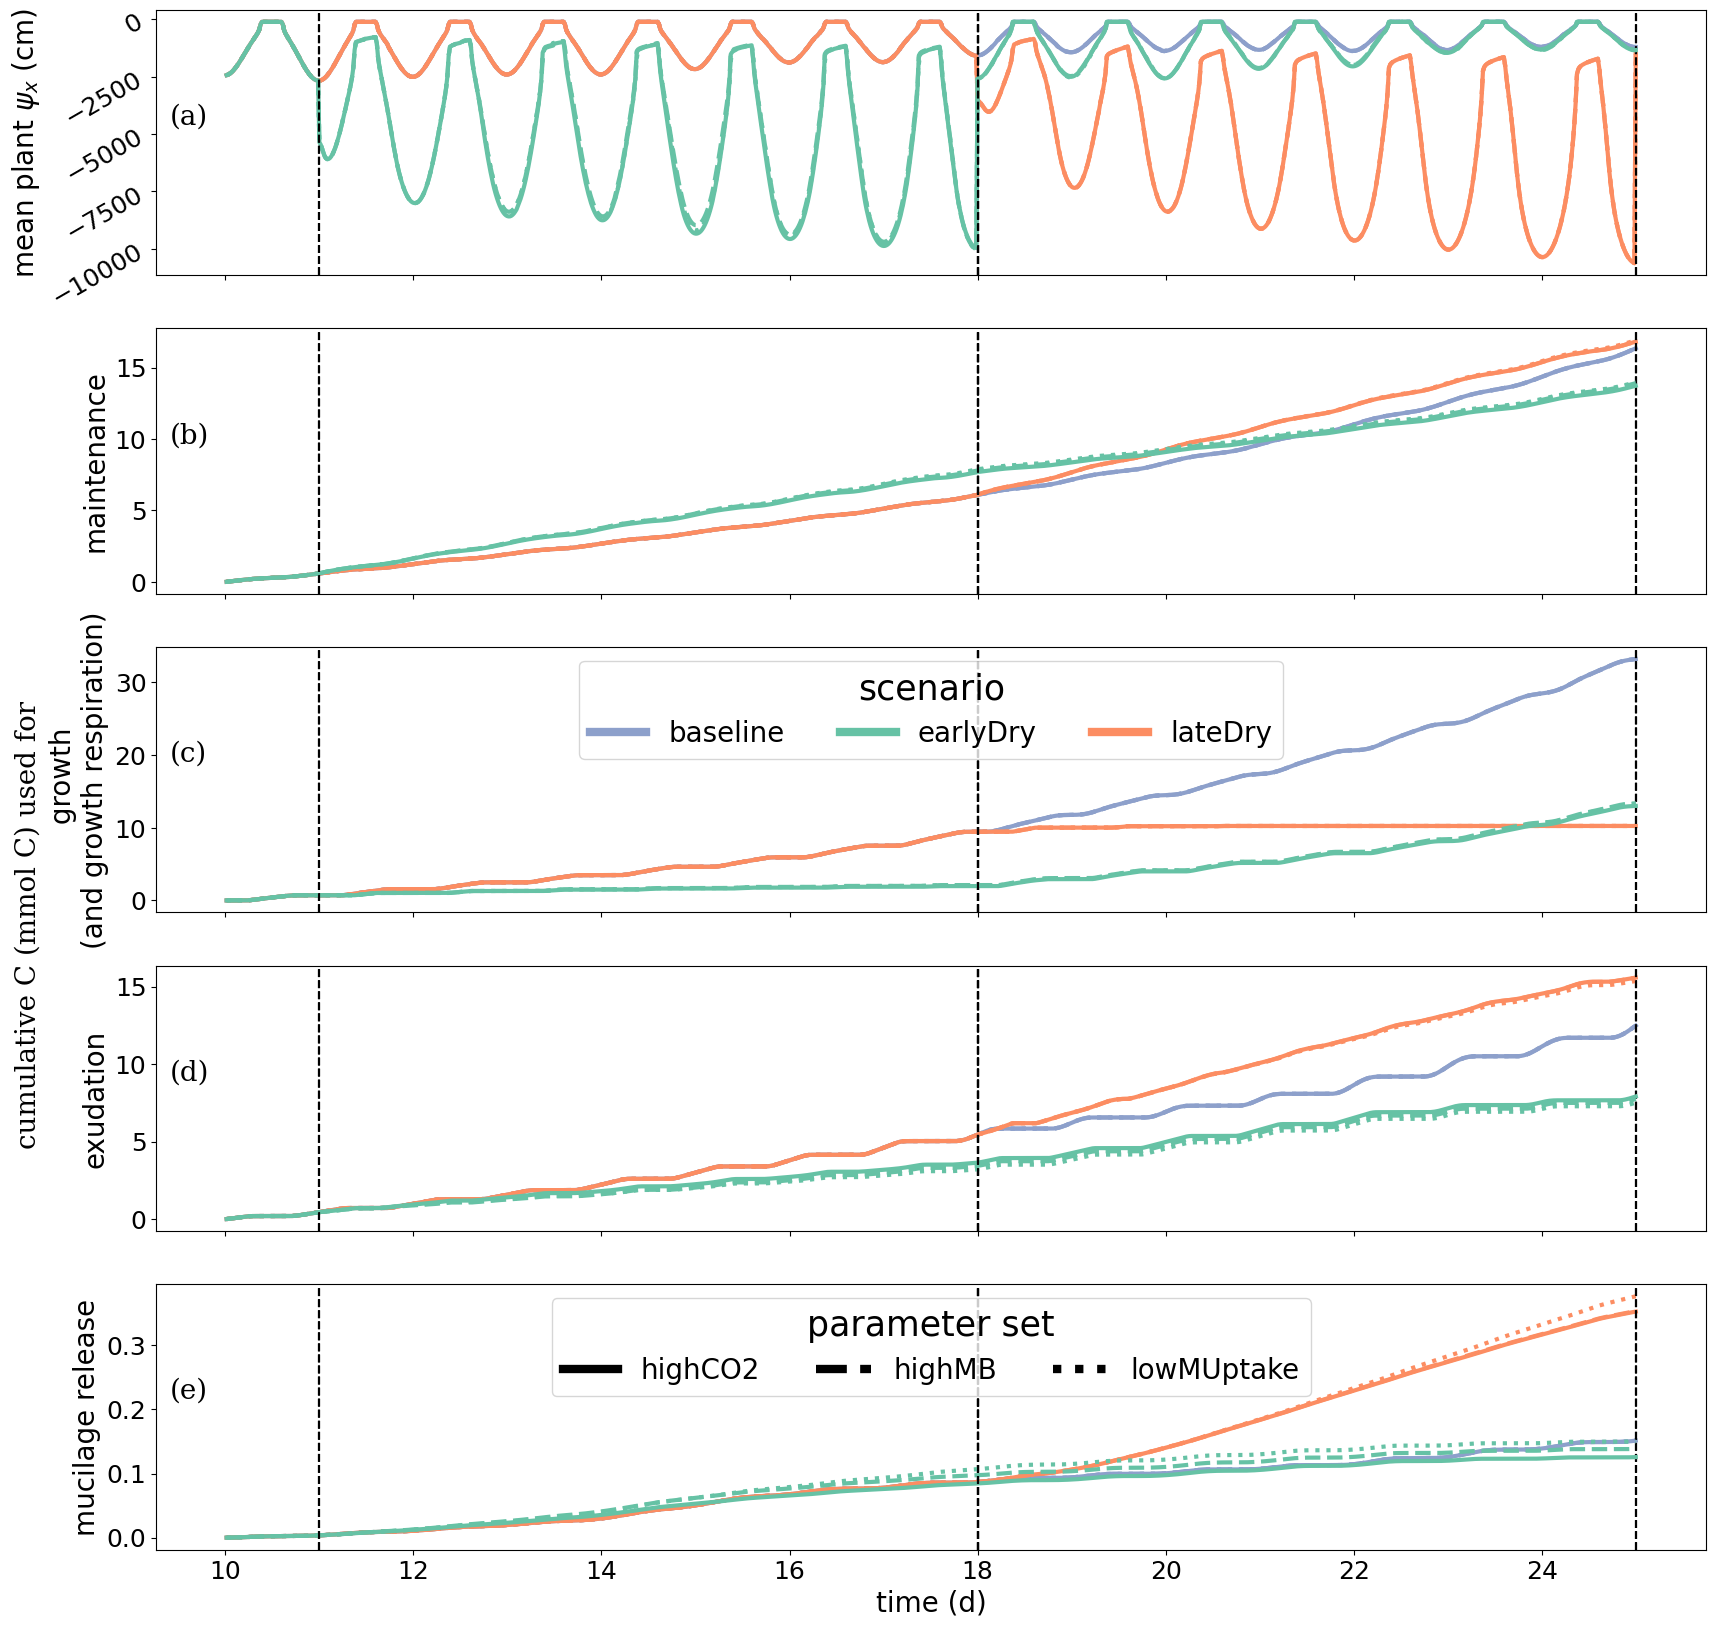

In [13]:
dotheplot(toplot =  ['psiXyl','Q_Rm','Q_Gr','Q_Exud','Q_Mucil'],#'Q_Exud_mean',
          namesyaxes={'psiXyl':"mean plant $\psi_x$", 'Resp':'Resp',
                      'Q_Gr':" growth\n(and growth respiration)", "Q_Rm":"maintenance","Q_Ag":"Q_Ag",
                      'Q_Exud':"exudation",'Q_Exud_mean':"exudation rate\n at root tip",
                      'Q_Mucil': "mucilage release"},forPrez=False,
          cumsum=True, df=dftemp, sizerows=20,sizecols_=20,ncols=1, 
          indexlegend1=2, indexlegend2=4)
plt.savefig('Cusage.png', dpi=25)